# Case 6

# Does weighting the reconstruction loss by feature stability help feedforward models detect contextual anomalies?

## Purpose of this notebook

This notebook demonstrates one of the reconstruction-loss variants studied in the thesis:

> Weighted MSE (WMSE) assigns a different importance to each feature — low-variance, normally-stable features are penalised more when they deviate, while noisy features are given lower weight. In multivariate time series, this can improve detection when features differ greatly in their variability or contribution to anomalous behaviour.

$$\mathcal{L}_{\text{WMSE}} = \frac{1}{N}\sum_{i=1}^{N} w_i (x_i - \hat{x}_i)^2$$

The thesis studies anomaly detection in streaming ERA5 weather data. It compares the impact of different configurations (VAE architecture, streaming and feature manipulation methods, reconstruction-loss shape) on VAEs with different deep learning models as encoder/decoder.

This testcase focuses on **contextual anomalies** (locally-plausible values that are abnormal for the season) and two architectures, **MLP-VAE** and **Transformer-VAE** (both plain, no cyclic time features), evaluated at three reconstruction-loss kinds.

---

For the complete experiment definitions, consult the thesis section associated with **4.3.4 Effects of Reconstruction Loss**, together with the YAML configuration files used by this suite.

## What is being compared?

The notebook runs six variants — two architectures, each at three reconstruction-loss kinds (`model.recon_loss_kind`):

| Variant | Loss | Meaning |
|---|---|---|
| **MLP-VAE** | MSE | Squared error — large deviations are amplified quadratically. |
| **MLP-VAE** | WMSE | Squared error, weighted per feature by inverse warmup-variance (see formula above). Weights are computed automatically from the warmup split — no manual tuning needed. |
| **MLP-VAE** | MAE | Absolute error — deviations are penalised linearly, not amplified. |
| **Transformer-VAE** | MSE | |
| **Transformer-VAE** | WMSE | |
| **Transformer-VAE** | MAE | |

All three are ways of scaling how much a large per-feature reconstruction error contributes to the anomaly score — MSE and WMSE both magnify large errors quadratically (WMSE additionally reweights *which* features matter most), unlike MAE, which is robust to large residuals.

## Findings being illustrated

For MLP-VAE and Transformer-VAE, WMSE is expected to improve on plain MSE simply by adding the default inverse-variance weights — configure `recon_loss_kind: wmse` in YAML.

MAE is also expected to perform well for Transformer-VAE. It is assumed that large squared gradients (from MSE or WMSE) can disrupt attention-based representations during online updates, as MAE limits the influence of any single high-error timestep on the gradient. This notebook demonstrates this pattern for Transformer-VAE (and the thesis's own finding extends this to LSTM-VAE as well).

Other weighting methods are possible, including using prior domain knowledge. 

This reduced notebook uses the full-scale ERA5 export by default (see `case01_clean_baseline.ipynb` for why), so results should be directionally close to the thesis, though exact metric values are not expected to match (single seed, this repo's own port of the training code).

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run the six reconstruction-loss variants on the same contextual-anomaly dataset.
4. Collect F1, AUC, precision, recall, and confusion-matrix counts.
5. Plot F1 as a function of reconstruction-loss kind, split by architecture.

### Expected runtime

Window-based runs use the GPU when available. All six variants share the same dataset; MLP-VAE runs are typically faster than Transformer-VAE.

### Before running

This notebook reads code and data from a **private GitHub repository**. You must:

1. Have permission to access the read-only repository with a fine-grained GitHub token.
2. In Colab, open the **Secrets** panel using the key icon.
3. Add the secret `GITHUB_TOKEN`.
4. Enable **Notebook access** for that secret.
5. Select **Runtime → Change runtime type → GPU**.
6. Choose **Runtime → Run all**.

The source ERA5 data and its licence information are described in `DATA_LICENSE.md`.

# Run Case

### Check GPU availability

In [5]:
%matplotlib inline
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


Environment check
-----------------
PyTorch version: 2.10.0+cu126
CUDA available: True
Selected device: Quadro RTX 6000


### Import and/or load Repo

In [2]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import userdata

    token = userdata.get("GITHUB_TOKEN")
    if not token:
        raise RuntimeError(
            "The Colab secret GITHUB_TOKEN is unavailable. "
            "Open the key icon in the left sidebar, add the token, "
            "and enable Notebook access."
        )

    if not REPO_DIR.exists():
        # Use an askpass helper so the token is not stored in the Git remote URL.
        askpass = Path("/content/git_askpass.sh")
        askpass.write_text(
            '#!/bin/sh\n'
            'case "$1" in\n'
            '  *Username*) echo "x-access-token" ;;\n'
            '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
            'esac\n'
        )
        askpass.chmod(0o700)

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"

        try:
            subprocess.run(
                ["git", "clone", REPO_URL, str(REPO_DIR)],
                check=True,
                env=env,
            )
        finally:
            askpass.unlink(missing_ok=True)

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("run_regression.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


Working directory: .
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### Step 1 — Configure the run

In [3]:
import os
import yaml

CASE_ID = "case06_reconstruction_loss"
SESSION_DIR = "runs/regression"
OUTPUT_DIR = f"{SESSION_DIR}/{CASE_ID}"

# Edit this directly — works the same locally and on Colab:
#   "full_split_files" (default) -> anom_types/contextual.yaml's own default —
#                      full-scale contextual data, pre-split into a
#                      warmup-only file (shared with case01 — the warmup
#                      portion is anomaly-free and identical regardless of
#                      anomaly type) and a test-only file with the
#                      contextual anomalies injected. Committed to the repo.
#   "mini_50pct"    -> the in-repo 377,784-row ERA5 slice (~50% of full-scale).
#                      Committed to the repo.
#   "mini_28pct"    -> the in-repo 210,384-row ERA5 slice (~28% of full-scale).
#                      Committed to the repo.
DATA_SOURCE = "full_split_files"

_DATA_SOURCE_LAYERS = {
    "full_split_files": None,   # anom_types/contextual.yaml's own default — no extra layer needed
    "mini_50pct": "../../modules/data_source/mini_50pct_contextual.yaml",
    "mini_28pct": "../../modules/data_source/mini_28pct_contextual.yaml",
}

_suite_source_path = f"notebooks/cases/{CASE_ID}_suite.yaml"
_suite_dir = os.path.dirname(os.path.abspath(_suite_source_path))

def _resolve(path):
    # base_config / config_layers entries are relative paths meant to be
    # read relative to the suite file's own directory (notebooks/cases/).
    # Resolving them to absolute paths here — rather than leaving them
    # relative — means the resolved copy stays correct no matter how deep
    # under OUTPUT_DIR it ends up being written.
    return path if os.path.isabs(path) else os.path.normpath(os.path.join(_suite_dir, path))

_data_source_layer = _DATA_SOURCE_LAYERS[DATA_SOURCE]

with open(_suite_source_path) as f:
    _suite = yaml.safe_load(f)

_suite["base_config"] = _resolve(_suite["base_config"])
for _run in _suite["runs"]:
    _layers = [_resolve(p) for p in _run["config_layers"]]
    if _data_source_layer:
        _layers.append(_resolve(_data_source_layer))
    _run["config_layers"] = _layers

# Written under OUTPUT_DIR (runs/, already gitignored and read-write) rather
# than notebooks/ (source-controlled, meant to stay read-only) — os.makedirs
# because OUTPUT_DIR won't exist yet on a fresh run.
os.makedirs(OUTPUT_DIR, exist_ok=True)
SUITE_PATH = f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved.yaml"
with open(SUITE_PATH, "w") as f:
    yaml.safe_dump(_suite, f, sort_keys=False)

print(f"DATA_SOURCE = {DATA_SOURCE!r} -> {_data_source_layer}")

DATA_SOURCE = 'full_split_files' -> None


#### Configuration file

The notebooks test suites combines a shared ERA5 configuration (`modules/era5_common.yaml`) with the architecture, anomaly type, stream mode, and reconstruction-loss settings for each run.

`DATA_SOURCE` may be configured to choose other datasets from the era5 data directory.
The default is `"full_split_files"`, which is the full-scale contextual-anomaly data, where warmup and test files are split (`data/era5/full_scale/split/era5_clean_warmup.csv` and `data/era5/full_scale/split/era5_contextual_test.csv`).

All variants use the same base configuration and evaluation procedure. The intended comparison is therefore the effect of **reconstruction-loss kind** on each architecture's contextual-anomaly detection.

#### Output Directory

During execution, the script creates a separate run directory in the repo for each variant under `OUTPUT_DIR` (`runs/regression/case06_reconstruction_loss` by default).

`notebooks/cases/case06_reconstruction_loss_suite.yaml` layers `modules/era5_common.yaml` with the architecture / anomaly-type / stream-mode fragments and the per-run `recon_loss_kind` override (see the suite file for the exact overrides).

### Step 2 Run the testsuite

### Command:

In [8]:
!python run_regression.py {SUITE_PATH} \
    --session {SESSION_DIR} --skip-existing

[suite] log     : runs/regression/suite.log
[suite] suite   : runs/regression/case06_reconstruction_loss/case06_reconstruction_loss_suite_resolved.yaml
[suite] session : runs/regression
[suite] base cfg: modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [0, 1, 2]  (3 slot(s))
[suite] 6 run(s) planned:
  [  1] MLP_mse  [case06_reconstruction_loss/case06_reconstruction_loss_suite_resolved]  (module: regression.run_trial)
  [  2] MLP_wmse  [case06_reconstruction_loss/case06_reconstruction_loss_suite_resolved]  (module: regression.run_trial)
  [  3] MLP_mae  [case06_reconstruction_loss/case06_reconstruction_loss_suite_resolved]  (module: regression.run_trial)
  [  4] TF_VAE_mse  [case06_reconstruction_loss/case06_reconstruction_loss_suite_resolved]  (module: regression.run_trial)
  [  5] TF_VAE_wmse  [case06_reconstruction_loss/case06_reconstruction_loss_suite_resolved]  (module: regression.run_trial)
  [  6] TF_VAE_mae  [case06_reconstruction_loss/case06_re

### Step 3 — Build a common comparison

#### The next command reads the predictions from every run and produces:

- a common performance table
- anomaly-score histograms
- an F1 comparison across variants
- confusion-matrix summaries
- seed-stability diagnostics, where applicable.

These outputs are saved under `OUTPUT_DIR/cross_compare/`.

### Command:

In [3]:
!python scripts/cross_compare.py {OUTPUT_DIR}

[cross] session : runs/regression/case06_reconstruction_loss
[cross] output  : runs/regression/case06_reconstruction_loss/cross_compare
[cross] 6 run(s) found:
  MLP_Contextual_mae                                  arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_mse                                  arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_wmse                                 arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  TF_VAE_Contextual_mae                               arch=TF_VAE  anomaly=Contextual  cyclic=False  mode=window
  TF_VAE_Contextual_mse                               arch=TF_VAE  anomaly=Contextual  cyclic=False  mode=window
  TF_VAE_Contextual_wmse                              arch=TF_VAE  anomaly=Contextual  cyclic=False  mode=window

[cross] Loading run data ...
  MLP_Contextual_mae ... ok
  MLP_Contextual_mse ... ok
  MLP_Contextual_wmse ... ok
  TF_VAE_Contextual_mae ... ok
  TF_VAE_Contextual_mse .

### Step 4 — Quantitative Results

### Command:

In [5]:
import pandas as pd
from IPython.display import display

performance_path = f"{OUTPUT_DIR}/cross_compare/performance_table.csv"
perf = pd.read_csv(performance_path)

columns = [
    "run_name", "arch", "anomaly", "variant",
    "f1", "auc", "precision", "recall",
    "tp", "fp", "fn",
]

loss_order = {"mse": 0, "wmse": 1, "mae": 2}
perf["_loss_order"] = perf["variant"].map(loss_order)

print("Comparison of reconstruction-loss variants")
display(
    perf[columns + ["_loss_order"]]
    .sort_values(["arch", "_loss_order"])
    .drop(columns="_loss_order")
    .reset_index(drop=True)
    .style.format({
        "f1": "{:.3f}",
        "auc": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
    })
)

Comparison of reconstruction-loss variants


,run_name,arch,anomaly,variant,f1,auc,precision,recall,tp,fp,fn
0,MLP_Contextual_mse,MLP,Contextual,mse,0.485,0.907,0.625,0.396,347,208,530
1,MLP_Contextual_wmse,MLP,Contextual,wmse,0.532,0.920,0.657,0.447,392,205,485
2,MLP_Contextual_mae,MLP,Contextual,mae,0.501,0.916,0.787,0.367,322,87,555
3,TF_VAE_Contextual_mse,TF_VAE,Contextual,mse,0.439,0.916,0.345,0.603,529,1005,348
4,TF_VAE_Contextual_wmse,TF_VAE,Contextual,wmse,0.674,0.953,0.767,0.601,527,160,350
5,TF_VAE_Contextual_mae,TF_VAE,Contextual,mae,0.581,0.934,0.867,0.437,383,59,494


#### Expected pattern

```text
MLP-VAE:         F1(MSE)  <   F1(WMSE)  ~  F1(MAE)   (WMSE improves on MSE; MAE close to WMSE)
Transformer-VAE: F1(MSE)  <<  F1(WMSE)  ~  F1(MAE)   (MSE is expected to be much lower than MAE and WMSE)
```

The testcase is successful when WMSE improves on plain MSE for both architectures, even if the exact values differ from the thesis. 

During the thesis experiment, Transformer-VAE's averaged results (for all seeds), illustrated that MAE has a slight advantage over WMSE.

### Step 5 — Qualitative support (Plots)

#### F1 / precision / recall by reconstruction-loss kind

##### Command:

  saved runs/regression/case06_reconstruction_loss/cross_compare/bars_recon_loss_f1_contextual.png
  saved runs/regression/case06_reconstruction_loss/cross_compare/bars_recon_loss_precision_contextual.png
  saved runs/regression/case06_reconstruction_loss/cross_compare/bars_recon_loss_recall_contextual.png


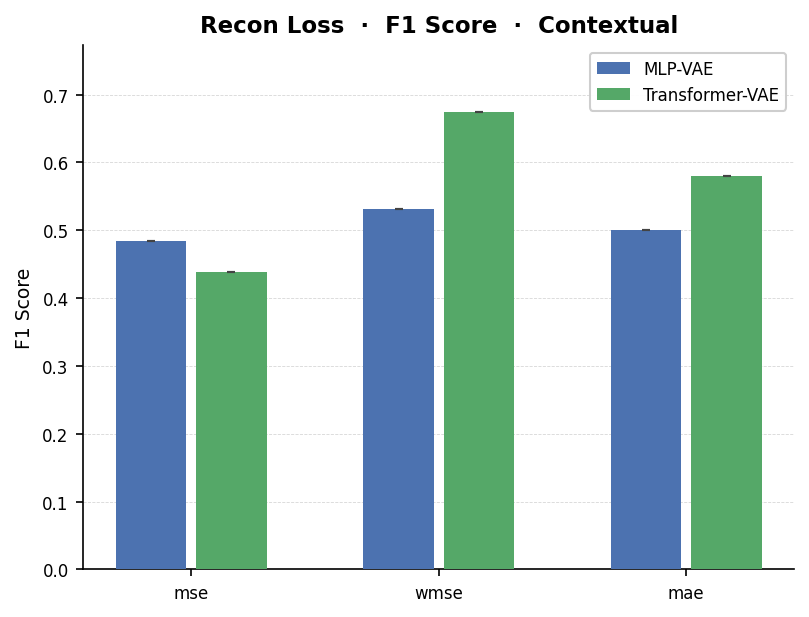

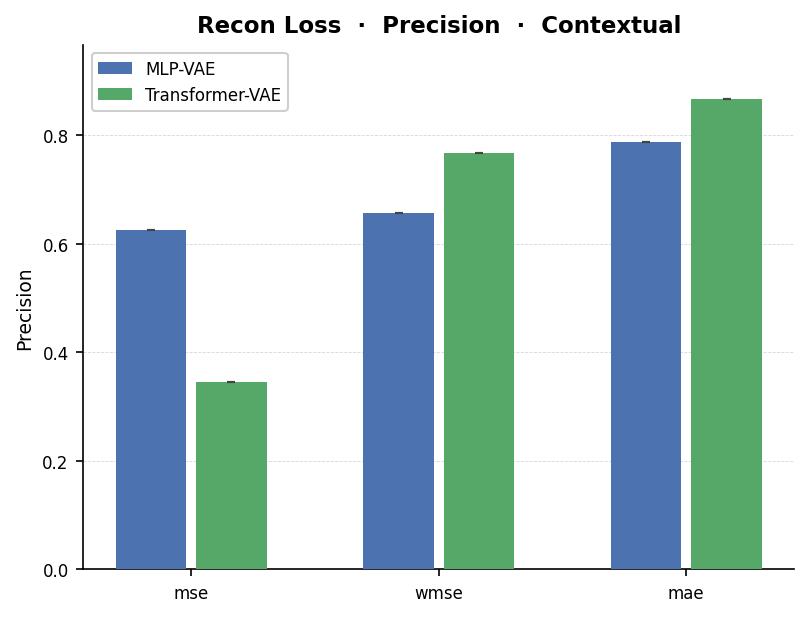

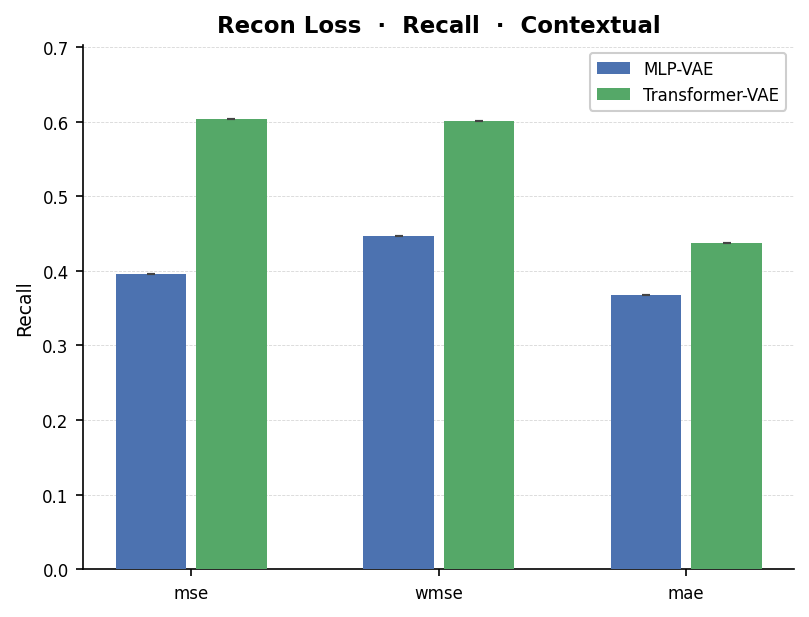

In [7]:
!python scripts/plot_categorical_bars.py {OUTPUT_DIR} --section recon_loss --metric f1
!python scripts/plot_categorical_bars.py {OUTPUT_DIR} --section recon_loss --metric precision
!python scripts/plot_categorical_bars.py {OUTPUT_DIR} --section recon_loss --metric recall

import glob
from IPython.display import Image, display

for p in sorted(glob.glob(f"{OUTPUT_DIR}/cross_compare/bars_recon_loss_*.png")):
    display(Image(filename=p))

Grouped bar chart — one bar per architecture, one group per reconstruction-loss kind (mse/wmse/mae), on a single seed.

#### Score histograms by reconstruction-loss kind

Reconstruction-loss kind isn't itself a quantitative metric — MSE, WMSE, and MAE scores aren't on a comparable scale, so a single F1-vs-loss-kind line plot can't show *why* one loss outperforms another. The score histograms below show it directly: 

##### Command:

Score histograms (normal vs anomaly), one file per architecture:


MLP,TF_VAE

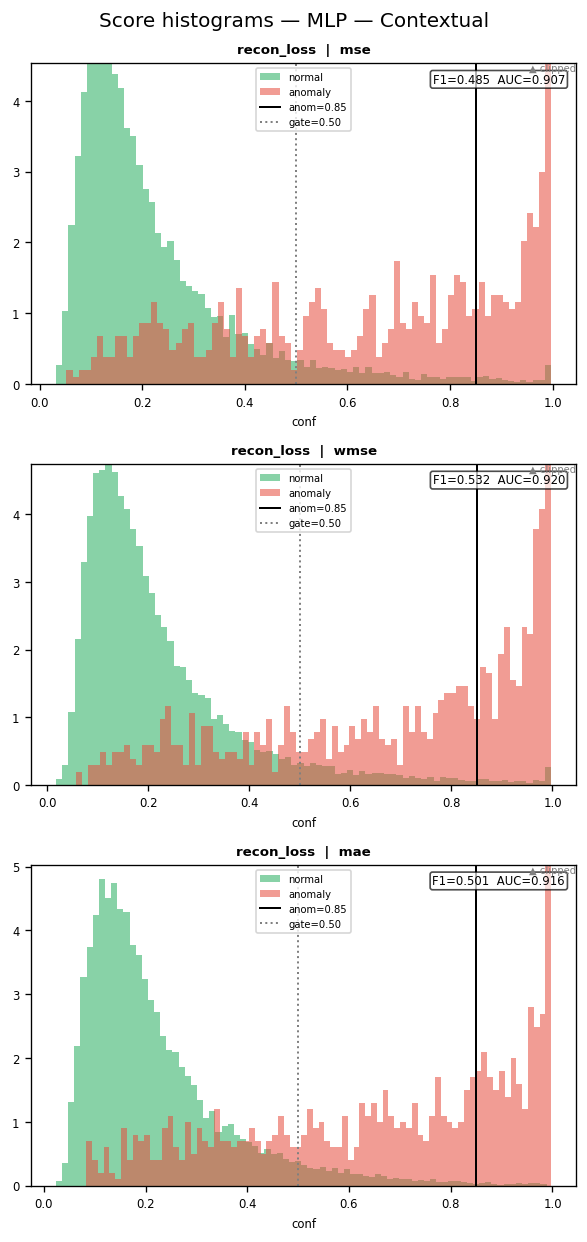
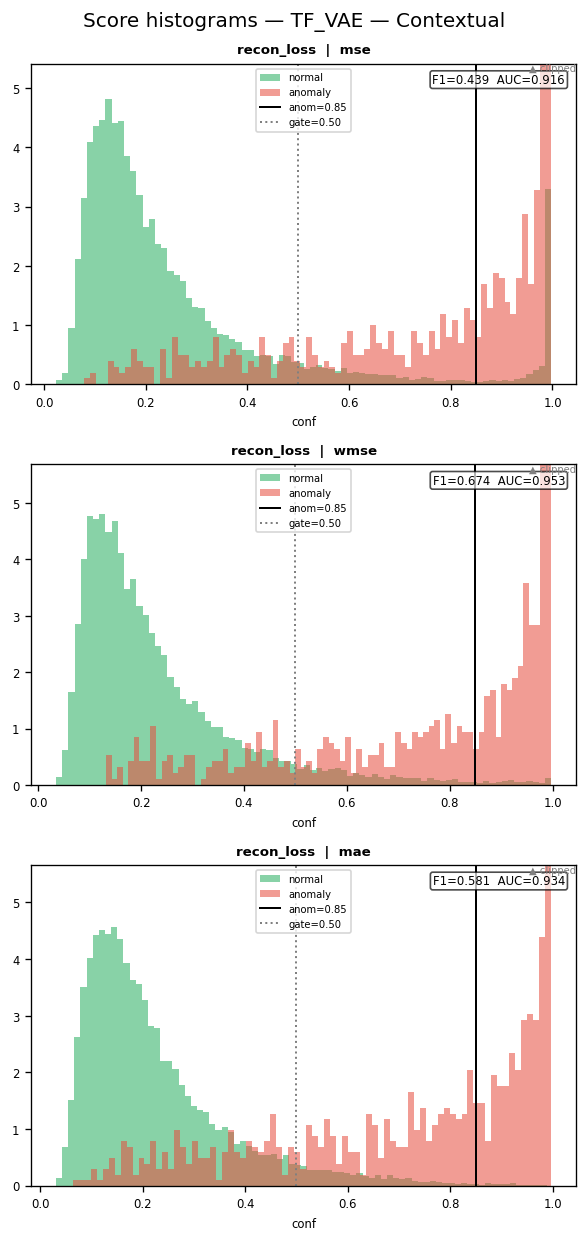

In [4]:
# Display the key comparison plot(s) inline, 2 per row, captioned by filename
import base64
import glob
from IPython.display import HTML, display

paths = sorted(glob.glob(f"{OUTPUT_DIR}/cross_compare/contextual/score_hist_*.png"))
print("Score histograms (normal vs anomaly), one file per architecture:")

n_cols = 2
rows_html = []
for i in range(0, len(paths), n_cols):
    row_paths = paths[i:i + n_cols]
    cells = []
    for path in row_paths:
        # caption from the filename (score_hist_{arch}.png), not the image
        # pixels — reliable because cross_compare.py names the file after
        # the architecture it plots.
        label = path.split("/")[-1].removeprefix("score_hist_").removesuffix(".png")
        with open(path, "rb") as f:
            b64 = base64.b64encode(f.read()).decode("ascii")
        cells.append(
            f'<td style="width:{100 // n_cols}%; padding:4px; text-align:center; vertical-align:top;">'
            f'<div style="font-weight:600; margin-bottom:4px;">{label}</div>'
            f'<img src="data:image/png;base64,{b64}" style="max-width:100%;"></td>'
        )
    rows_html.append("<tr>" + "".join(cells) + "</tr>")

display(HTML(f'<table style="width:100%; border-collapse:collapse;">{"".join(rows_html)}</table>'))

for each architecture per loss kind, overlapping normal (green) and anomaly (red) score distributions. Better separation between the two distributions — not a higher or lower score in isolation — is what should track with the F1 differences in the table above.

#### The histograms can indicate, among other things:

1. Whether WMSE shows tighter, better-separated normal/anomaly distributions than MSE for both architectures, using only the automatically-computed default weights.
2. Whether MAE shows better separation than WMSE for Transformer-VAE specifically.
3. Whether MLP-VAE's histogram pattern across the three losses differs from Transformer-VAE's.

### Main takeaway

Weighting the reconstruction loss by feature stability (WMSE) can improve detection over plain MSE without any manual tuning — the weights are derived automatically from the warmup split's per-feature variance. For Transformer-VAE, MAE results indicate that large squared gradients (from MSE) may disrupt attention-based representations during online updates. MAE's linear penalty limits the influence of any single high-error timestep. The choice of reconstruction loss is therefore not purely about how features are weighted relative to each other — it also interacts with how the architecture itself updates gradients online.

## Scope of this testcase

This notebook is a compact demonstration, not a full reproduction of every reconstruction-loss experiment reported in the thesis. With `DATA_SOURCE = "full_split_files"` (the default) it runs on the full-scale contextual-anomaly data. With `DATA_SOURCE = "mini_50pct"` / `"mini_28pct"` a shorter ERA5 interval is used instead — useful for a quick check, but see `case01_clean_baseline.ipynb` for why it can give different results than the full-scale data.

This notebook only tests MLP-VAE and Transformer-VAE. The thesis's own MAE-vs-WMSE finding also extends to LSTM-VAE, which is not covered here.

Conclusions should be based on the **direction and consistency of the F1-vs-recon_loss trend per architecture**, rather than exact numerical agreement with the thesis figures (single seed, this repo's own port of the training code).

For the complete experiment definitions, consult the thesis section on Weighted Mean Squared Error (WMSE), together with the YAML configuration files used by this suite.